# Comparison of samples

Apply to summary files (output from summary_celltypes_IHOPE.py) in CSV format.

In [34]:
import sys
from pathlib import Path
import numpy as np
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [70]:
import scripts
import importlib
importlib.reload(scripts)

<module 'scripts' from '/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/__init__.py'>

In [72]:
from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_clustermap,
    plot_celltype_stacked_barplot
)

Define file names and sample names. Use the output from cell 1 to complete cell 2.

In [36]:
# Make a "fill the gap" template
summaries_dir = Path("../results/reports/zscore")
files = sorted(summaries_dir.glob("celltype_summary_*_zscore_IHOPE_summary.csv"))

print("name_map = {")
for f in files:
    print(f'    "{f.name}": "",')
print("}")

name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE14_MesLN_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE20_MedLN_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE20_Spleen_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE26_MedLN_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE26_Spleen_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE27_MedLN_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE27_Spleen_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE39_MedLN_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE39_MesLN_A_filtered_zscore_IHOPE_summary.csv": "",
    "celltype_summary_IHOPE39_MesLN_B_

In [37]:
name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_zscore_IHOPE_summary.csv": "IHOPE14 MedLN Bottom Left",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_zscore_IHOPE_summary.csv": "IHOPE14 MedLN Bottom Right",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_zscore_IHOPE_summary.csv": "IHOPE14 MedLN Top Right",
    "celltype_summary_IHOPE14_MesLN_filtered_zscore_IHOPE_summary.csv": "IHOPE14 MesLN",
    "celltype_summary_IHOPE20_MedLN_filtered_zscore_IHOPE_summary.csv": "IHOPE20 MedLN",
    "celltype_summary_IHOPE20_Spleen_filtered_zscore_IHOPE_summary.csv": "IHOPE20 Spleen",
    "celltype_summary_IHOPE26_MedLN_filtered_zscore_IHOPE_summary.csv": "IHOPE26 MedLN",
    "celltype_summary_IHOPE26_Spleen_filtered_zscore_IHOPE_summary.csv": "IHOPE26 Spleen",
    "celltype_summary_IHOPE27_MedLN_filtered_zscore_IHOPE_summary.csv": "IHOPE27 MedLN",
    "celltype_summary_IHOPE27_Spleen_filtered_zscore_IHOPE_summary.csv": "IHOPE27 Spleen",
    "celltype_summary_IHOPE39_MedLN_filtered_zscore_IHOPE_summary.csv": "IHOPE39 MedLN",
    "celltype_summary_IHOPE39_MesLN_A_filtered_zscore_IHOPE_summary.csv": "IHOPE39 MesLN A",
    "celltype_summary_IHOPE39_MesLN_B_filtered_zscore_IHOPE_summary.csv": "IHOPE39 MesLN B",
    "celltype_summary_IHOPE39_Spleen_filtered_zscore_IHOPE_summary.csv": "IHOPE39 Spleen",
}

In [38]:
file_map = {
    sample: summaries_dir / fname
    for fname, sample in name_map.items()
}

In [39]:
# Sanity check
for sample, path in file_map.items():
    print(sample, ": ", path.name)

IHOPE14 MedLN Bottom Left :  celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_zscore_IHOPE_summary.csv
IHOPE14 MedLN Bottom Right :  celltype_summary_IHOPE14_MedLN_BottomRight_filtered_zscore_IHOPE_summary.csv
IHOPE14 MedLN Top Right :  celltype_summary_IHOPE14_MedLN_TopRight_filtered_zscore_IHOPE_summary.csv
IHOPE14 MesLN :  celltype_summary_IHOPE14_MesLN_filtered_zscore_IHOPE_summary.csv
IHOPE20 MedLN :  celltype_summary_IHOPE20_MedLN_filtered_zscore_IHOPE_summary.csv
IHOPE20 Spleen :  celltype_summary_IHOPE20_Spleen_filtered_zscore_IHOPE_summary.csv
IHOPE26 MedLN :  celltype_summary_IHOPE26_MedLN_filtered_zscore_IHOPE_summary.csv
IHOPE26 Spleen :  celltype_summary_IHOPE26_Spleen_filtered_zscore_IHOPE_summary.csv
IHOPE27 MedLN :  celltype_summary_IHOPE27_MedLN_filtered_zscore_IHOPE_summary.csv
IHOPE27 Spleen :  celltype_summary_IHOPE27_Spleen_filtered_zscore_IHOPE_summary.csv
IHOPE39 MedLN :  celltype_summary_IHOPE39_MedLN_filtered_zscore_IHOPE_summary.csv
IHOPE39 MesLN A :  cellty

Generate the combined data frame:

In [40]:
df = load_celltype_summaries(file_map=file_map)

### Donor-grouping:

In [41]:
donor_map = {
    "IHOPE14 MedLN Bottom Left": "IHOPE14",
    "IHOPE14 MedLN Bottom Right": "IHOPE14",
    "IHOPE14 MedLN Top Right": "IHOPE14",
    "IHOPE14 MesLN": "IHOPE14",
    "IHOPE20 MedLN": "IHOPE20",
    "IHOPE20 Spleen": "IHOPE20",
    "IHOPE26 MedLN": "IHOPE26",
    "IHOPE26 Spleen": "IHOPE26",
    "IHOPE27 MedLN": "IHOPE27",
    "IHOPE27 Spleen": "IHOPE27",
    "IHOPE39 MedLN": "IHOPE39",
    "IHOPE39 MesLN A": "IHOPE39",
    "IHOPE39 MesLN B": "IHOPE39",
    "IHOPE39 Spleen": "IHOPE39",
}

df["donor"] = df["sample"].map(donor_map)

### Tissue-grouping:

In [42]:
tissue_map = {
    "IHOPE14 MedLN Bottom Left": "MedLN",
    "IHOPE14 MedLN Bottom Right": "MedLN",
    "IHOPE14 MedLN Top Right": "MedLN",
    "IHOPE14 MesLN": "MesLN",
    "IHOPE20 MedLN": "MedLN",
    "IHOPE20 Spleen": "Spleen",
    "IHOPE26 MedLN": "MedLN",
    "IHOPE26 Spleen": "Spleen",
    "IHOPE27 MedLN": "MedLN",
    "IHOPE27 Spleen": "Spleen",
    "IHOPE39 MedLN": "MedLN",
    "IHOPE39 MesLN A": "MesLN",
    "IHOPE39 MesLN B": "MesLN",
    "IHOPE39 Spleen": "Spleen",
}

df["tissue"] = df["sample"].map(tissue_map)

Using mean  (avoid dominance of large samples):

In [43]:
df_tissue = (
    df.groupby(["tissue", "level", "cell_type"], as_index=False)
      .agg(pct_total=("pct_total", "mean"))
)

Decide how you want to handle unannotated cells:

In [44]:
DROP_UNCLASSIFIED = True   # drop 'unclassified' and rescale to 100, applied in the matrix and barplot calls below
HIDE_UNCLASSIFIED = False  # keep percentages as-is, just drop the unclassified row from heatmaps

Order of cell types for heatmaps:

In [69]:
# Structural / non-immune cell types, dropped when immune_only=True
structural_cell_types = [
    "Blood_Endothelial",
    "Lymphatic_Endothelial",
    "Basement_Membrane",
    "Fibroblast",
    "Stromal",
    "FDC"
]

# Lineage subsets for the per-lineage breakdown barplots
lineage_subsets = {
    "T": [
        "Activated_CD4", "Activated_CD8", "TCM_CD4", "TCM_CD8",
        "TEM_CD4", "TEM_CD8", "TEMRA_CD4", "TEMRA_CD8",
        "TN_CD4", "TN_CD8", "Treg", "TfH_like", "T_terminal",
    ],
    "B": [
        # including both old and new naming
        "B_GC_follicular", "B_follicular_memory",
        "B_plasmablast_extrafollicular", "B_extrafollicular_memory",
        "B_naive",
    ],
    "Myeloid": [
        "Monocyte_Macrophage", "cDC1", "cDC2",
    ],
}

# Manual row order for heatmaps, grouping related subtypes together.
celltype_order = [
    # type level
    "T", "NK", "B", "Myeloid", "Stromal", "Endothelial", "unclassified",
    # intermediate level
    "T_naive", "T_memory", "CD4_T", "CD8_T", "B_memory",
    # subtype: CD4 T cells
    "TN_CD4", "TCM_CD4", "TEM_CD4", "TEMRA_CD4", "Activated_CD4", "Treg", "TfH_like",
    # subtype: CD8 T cells
    "TN_CD8", "TCM_CD8", "TEM_CD8", "TEMRA_CD8", "Activated_CD8",
    # subtype: other T
    "T_terminal",
    # subtype: B cells (old and new names kept adjacent)
    "B_naive",
    "B_GC_follicular", "B_follicular_memory",
    "B_plasmablast_extrafollicular", "B_extrafollicular_memory",
    # subtype: myeloid
    "Monocyte_Macrophage", "cDC1", "cDC2",
    # subtype: stromal / structural (only appear when not immune_only)
    "FDC", "Fibroblast", "Basement_Membrane",
    "Blood_Endothelial", "Lymphatic_Endothelial",
]

### Cell type matrices

Builds both the full (all cell types) and immune-only matrices, for sample-level and tissue-level grouping. Pick which one to plot with `IMMUNE_ONLY` below.

In [52]:
matrix_all = pivot_for_heatmap(
    df, celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_immune = pivot_for_heatmap(
    df, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order,
)

matrix_tissue_all = pivot_for_tissue_heatmap(
    df_tissue, celltype_order=celltype_order,
    drop_unclassified=DROP_UNCLASSIFIED, renormalise=DROP_UNCLASSIFIED,
)
matrix_tissue_immune = pivot_for_tissue_heatmap(
    df_tissue, immune_only=True, renormalise=True,
    structural_cell_types=structural_cell_types,
    celltype_order=celltype_order,
)

## Plots

**Cell type heatmap:**

Choose if you want to use raw percentages or log-scaled in the first block.

In [53]:
USE_LOG = False      # set True for log scaled percentages
IMMUNE_ONLY = True   # set False to use the full matrix (structural cell types and unclassified included)

scale_label = "log"    if USE_LOG else "linear"
cbar_label  = "Log percentage (+0.1)" if USE_LOG else "Percentage"

matrix = matrix_immune if IMMUNE_ONLY else matrix_all

plot_matrix = np.log10(matrix + 0.1) if USE_LOG else matrix

if HIDE_UNCLASSIFIED:
    plot_matrix = plot_matrix.drop(index="unclassified", errors="ignore")

Generate plots:

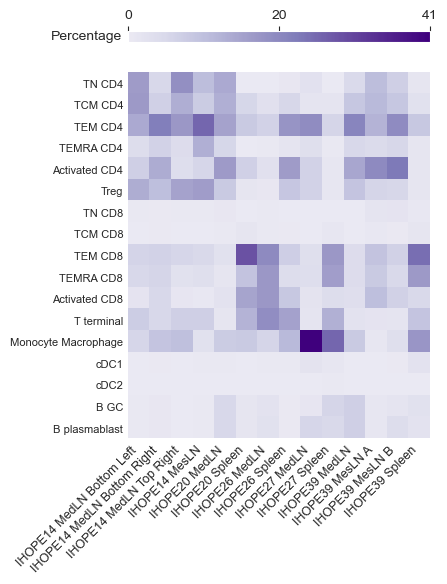

In [54]:
plot_celltype_heatmap(
    plot_matrix,
    scale = scale_label,
    colorbar_legend=cbar_label
)

Clustered:

In [ ]:
# Both axes clustered:

plot_celltype_clustermap(
    plot_matrix,
    colorbar_legend=cbar_label,
    scale=scale_label
)

In [ ]:
# Only cluster samples (X-axis):

plot_celltype_clustermap(
    plot_matrix,
    colorbar_legend=cbar_label,
    scale=scale_label,
    cluster_rows=False,
    cluster_cols=True
)

Correlation metric can also be used, this can be an advantage when sample sizes differ, which they do here

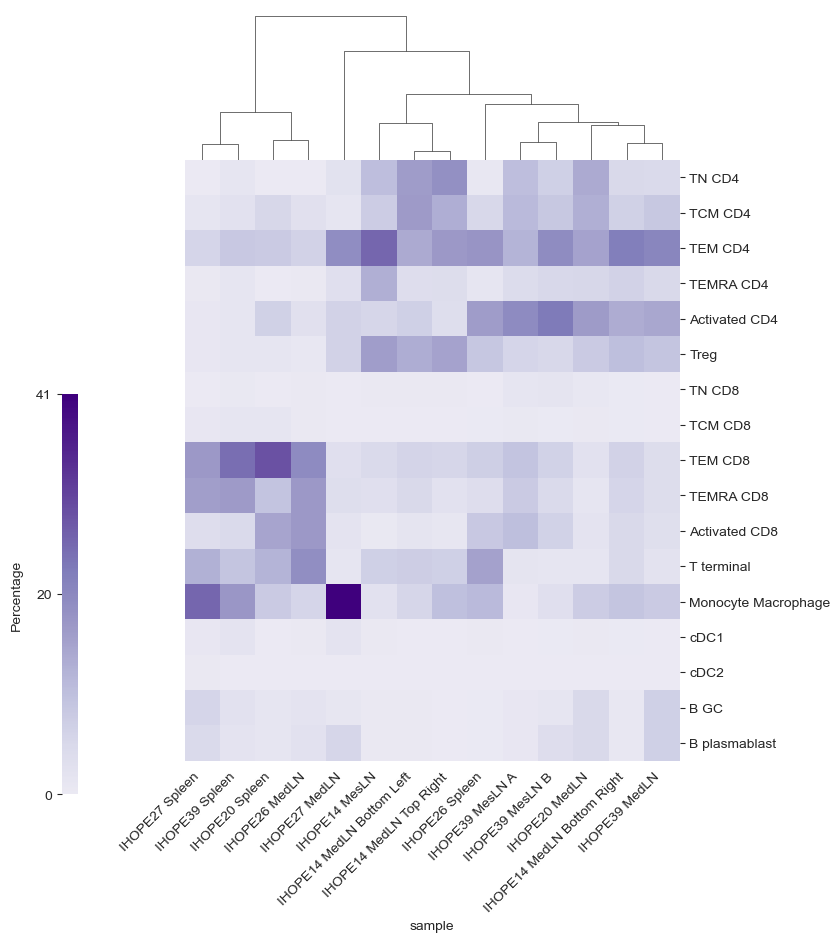

In [55]:
# With correlation metric instead of Euclidean

plot_celltype_clustermap(
    plot_matrix,
    scale=scale_label,
    colorbar_legend=cbar_label,
    cluster_rows=False,
    cluster_cols=True,
    metric="correlation"
)

**Tissue-grouped**

Select raw percentages or log-scaled in the first block.

In [56]:
USE_LOG = False  # set True for log scaled percentages

matrix_tissue = matrix_tissue_immune if IMMUNE_ONLY else matrix_tissue_all

plot_matrix_tissue = np.log10(matrix_tissue + 0.1) if USE_LOG else matrix_tissue
scale_label  = "log"    if USE_LOG else "linear"
cbar_label   = "Percentage (log +0.1)" if USE_LOG else "Percentage"

if HIDE_UNCLASSIFIED:
    plot_matrix_tissue = plot_matrix_tissue.drop(index="unclassified", errors="ignore")

Raw percentages:

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/comparison.py:433: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


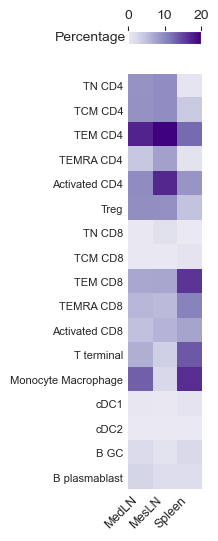

In [57]:
plot_celltype_heatmap(
    plot_matrix_tissue,
    colorbar_legend=cbar_label,
    scale=scale_label
)

### Stacked barplots

Stacked barplot for broad/lineage cell types:

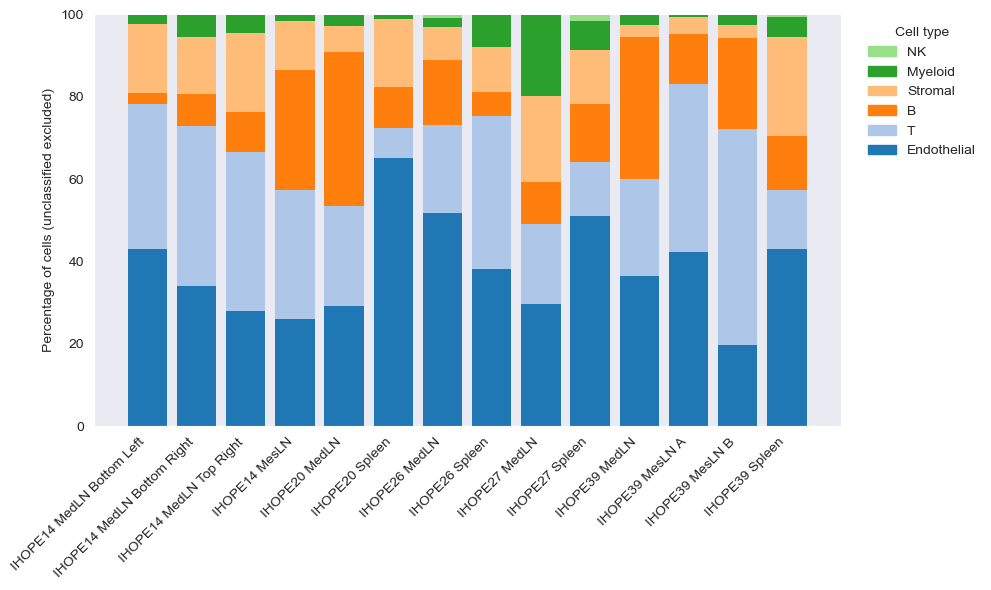

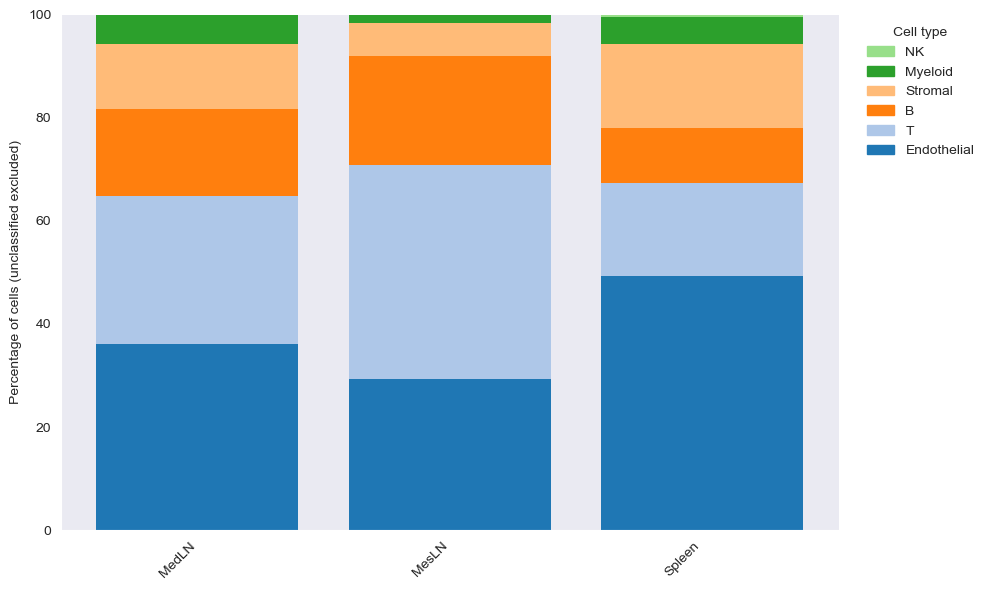

{'Endothelial': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'T': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'B': (1.0, 0.4980392156862745, 0.054901960784313725),
 'Stromal': (1.0, 0.7333333333333333, 0.47058823529411764),
 'Myeloid': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'NK': (0.596078431372549, 0.8745098039215686, 0.5411764705882353)}

In [64]:
palette_type = plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    drop_unclassified=DROP_UNCLASSIFIED,
    ylim=(0,100)
)

plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    x="tissue",
    palette=palette_type,
    drop_unclassified=DROP_UNCLASSIFIED,
    ylim=(0, 100)
)

Intermediate cell types (note that they do not add up to 100% and the Y axis limits may need tuning):

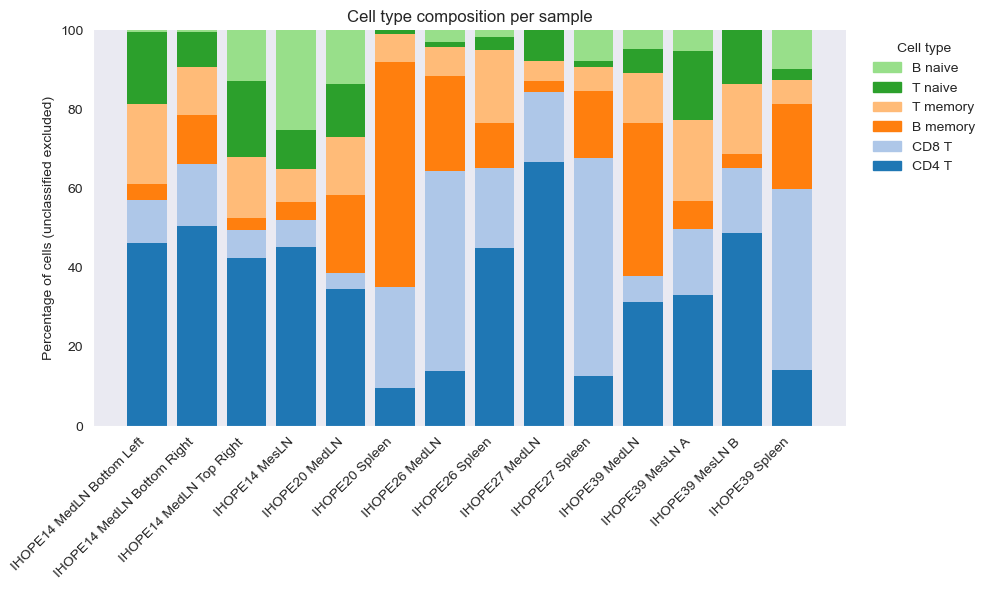

In [67]:
palette_intermediate = plot_celltype_stacked_barplot(
    df,
    levels=["intermediate"],
    x="sample",
    title="Cell type composition per sample",
    drop_unclassified=DROP_UNCLASSIFIED,
#    ylim = (0, 100)
)

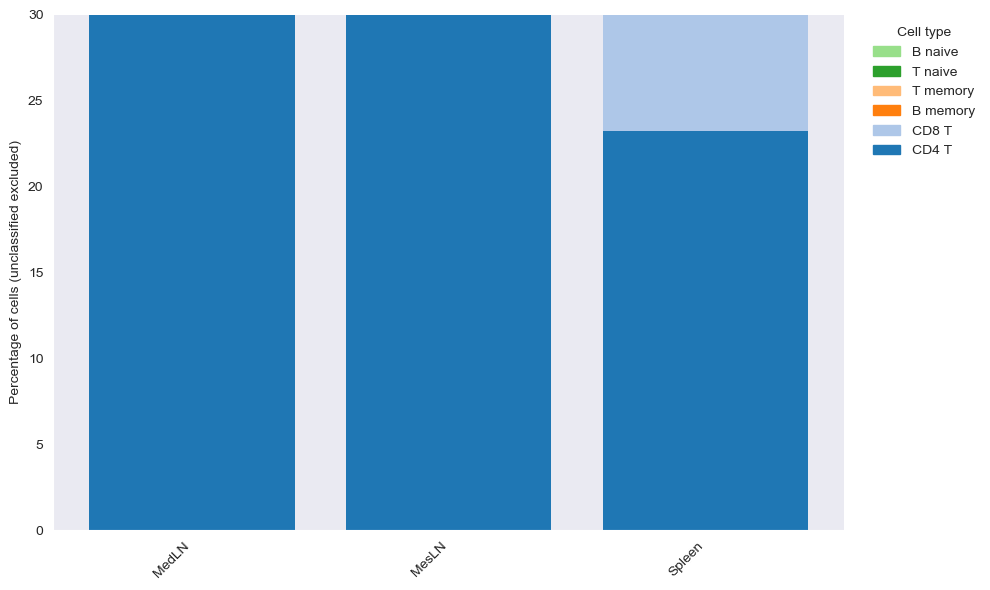

{'CD4_T': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'CD8_T': (0.6823529411764706, 0.7803921568627451, 0.9098039215686274),
 'B_memory': (1.0, 0.4980392156862745, 0.054901960784313725),
 'T_memory': (1.0, 0.7333333333333333, 0.47058823529411764),
 'T_naive': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'B_naive': (0.596078431372549, 0.8745098039215686, 0.5411764705882353)}

In [66]:
plot_celltype_stacked_barplot(
    df_tissue,
    levels=["intermediate"],
    x="tissue",
    palette=palette_intermediate,  # reuse colors
    drop_unclassified=DROP_UNCLASSIFIED,
    ylim = (0, 30)
)

Immune cells only, rescaled to 100% (main figure version):

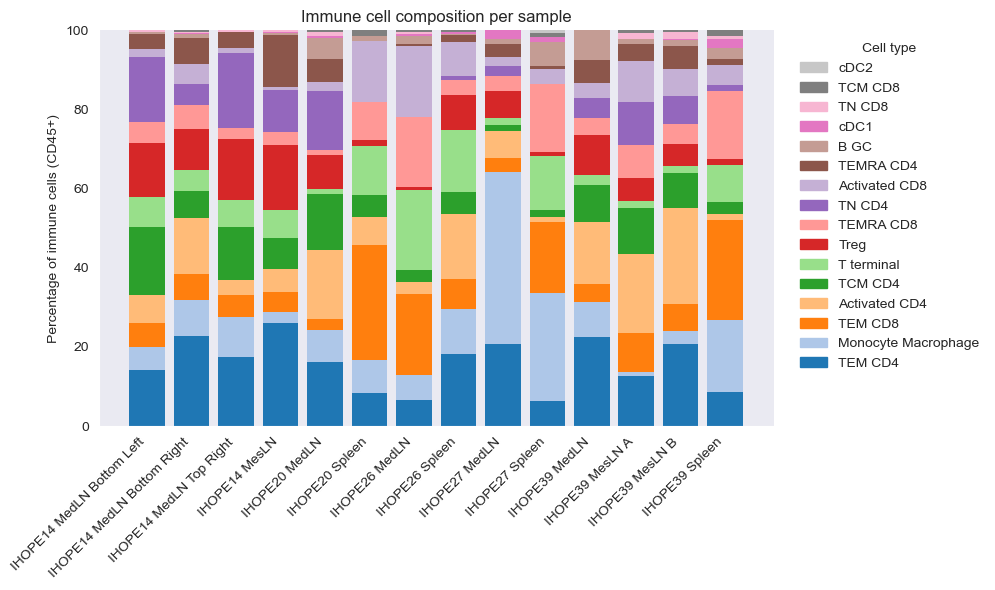

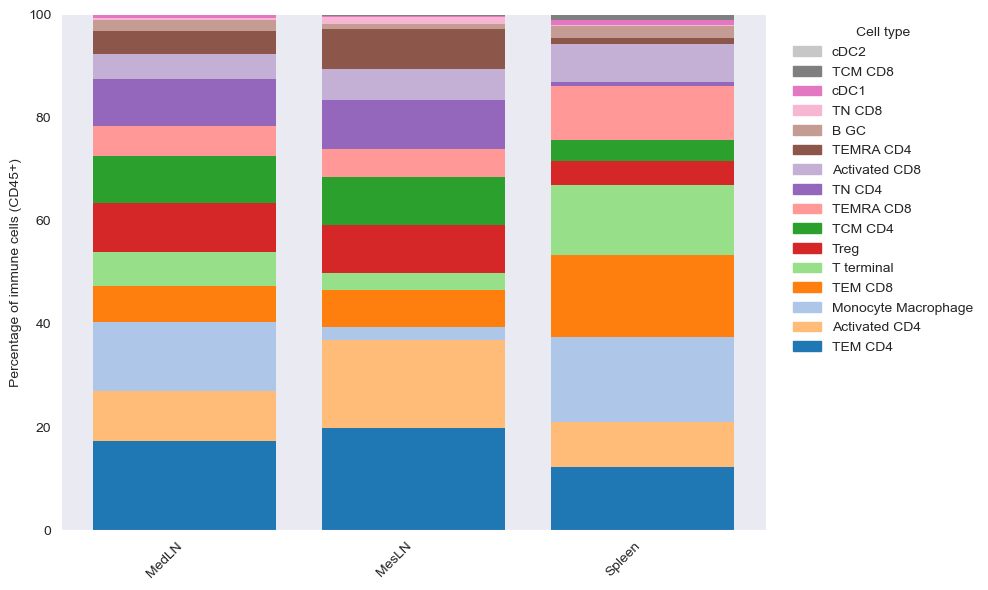

{'TEM_CD4': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'Monocyte_Macrophage': (0.6823529411764706,
  0.7803921568627451,
  0.9098039215686274),
 'TEM_CD8': (1.0, 0.4980392156862745, 0.054901960784313725),
 'Activated_CD4': (1.0, 0.7333333333333333, 0.47058823529411764),
 'TCM_CD4': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'T_terminal': (0.596078431372549, 0.8745098039215686, 0.5411764705882353),
 'Treg': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'TEMRA_CD8': (1.0, 0.596078431372549, 0.5882352941176471),
 'TN_CD4': (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 'Activated_CD8': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 'TEMRA_CD4': (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 'B_GC': (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 'cDC1': (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 'TN_CD8': (0.9686274509803922, 0.7137254901960784, 0

In [74]:
palette_immune = plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    immune_only=True,
    structural_cell_types=structural_cell_types,
    title="Immune cell composition per sample",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    df_tissue,
    levels=["subtype"],
    x="tissue",
    palette=palette_immune,
    structural_cell_types=structural_cell_types,
    immune_only=True,
    ylim=(0, 100)
)

Lineage breakdowns, each rescaled to sum to 100% within that lineage:

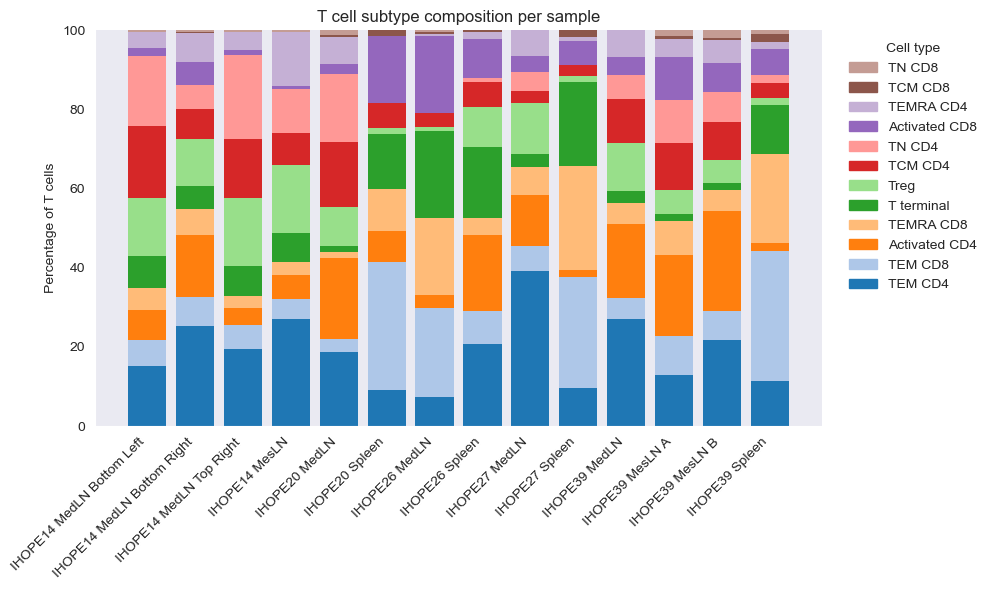

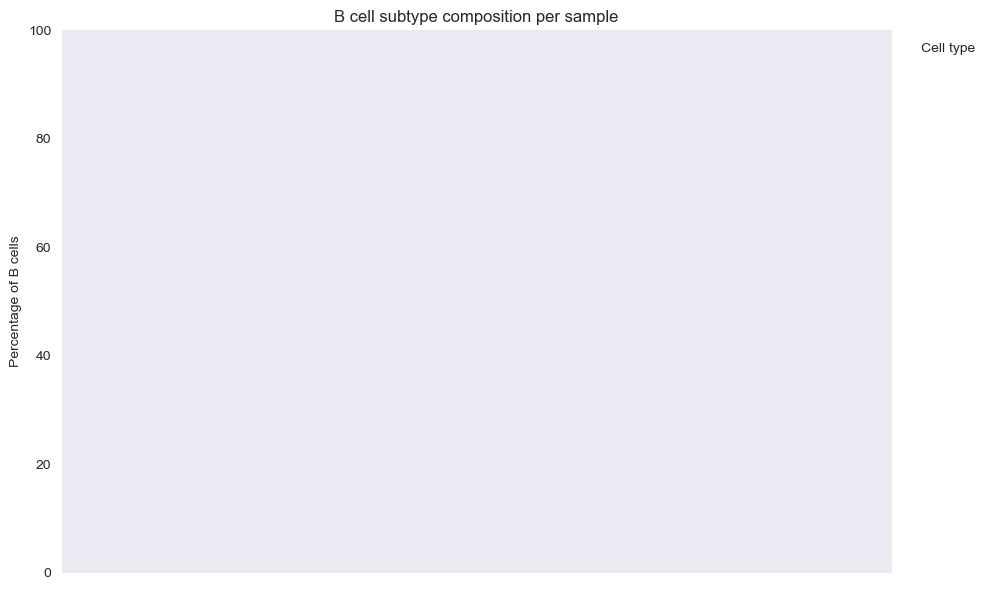

In [ ]:
plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    lineage_subset="T",
    lineage_subsets=lineage_subsets,
    title="T cell subtype composition per sample",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    lineage_subset="B",
    lineage_subsets=lineage_subsets,
    title="B cell subtype composition per sample",
    ylim=(0, 100)
)

plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    lineage_subset="Myeloid",
    lineage_subsets=lineage_subsets,
    title="DC and monocyte/macrophage subtype composition per sample",
    ylim=(0, 100)
)